In [37]:
import pandas as pd
import plotly as pltly
import plotly.express as px

In [38]:
#Reading in data
cellar = pd.read_csv("C:/Users/CPSULLIVAN/OneDrive - UNCG/Research Items/Test_Data/MovieCellar.csv")
cellar25 = pd.read_csv("C:/Users/CPSULLIVAN/OneDrive - UNCG/Research Items/Test_Data/MovieCellar_25.csv")

In [39]:
#Renaming variables in a range
start_col, end_col = "Score", "ScorediffLeftPer"
suffix = "_cellar-2024"

start_idx = cellar.columns.get_loc(start_col)
end_idx = cellar.columns.get_loc(end_col) + 1  # inclusive of end_col

# Build new column list
cols = list(cellar.columns)
cols[start_idx:end_idx] = [c + suffix for c in cols[start_idx:end_idx]]
cellar.columns = cols

cellar = cellar.rename(columns={"Year" : "Year_cellar-2024"})

#Renaming variables in a range
start_col, end_col = "Score", "ScorediffLeftPer"
suffix = "_cellar-2025"

start_idx = cellar25.columns.get_loc(start_col)
end_idx = cellar25.columns.get_loc(end_col) + 1  # inclusive of end_col

# Build new column list
cols = list(cellar25.columns)
cols[start_idx:end_idx] = [c + suffix for c in cols[start_idx:end_idx]]
cellar25.columns = cols

cellar25 = cellar25.rename(columns={"Year" : "Year_cellar-2025"})

In [40]:
#Sanity check
cellar.head(5)

,Year_cellar-2024,Movie,Score_cellar-2024,ScoreNow_cellar-2024,ScoreNowDif_cellar-2024,ScoreNowDifZ_cellar-2024,ScoreByDays_cellar-2024,ScorediffLeft_cellar-2024,ScorediffLeftPer_cellar-2024
0,2019,Booksmart,75.314286,77.685714,2.371429,3.138011,0.001181,0.096065,9.606481
1,2019,TheGoodLiar,62.485714,63.628571,1.142857,1.549025,0.000624,0.030465,3.046458
2,2019,JoJoRabbit,75.500000,76.228571,0.728571,1.013204,0.000396,0.029738,2.973761
3,2019,ReadyOrNot,69.385714,70.114286,0.728571,1.013204,0.000380,0.023798,2.379841
4,2019,Harriet,69.985714,70.628571,0.642857,0.902345,0.000348,0.021418,2.141837


In [41]:
cellar25.head(5)

,Year_cellar-2025,Movie,Score_cellar-2025,ScoreNow_cellar-2025,ScoreNowDif_cellar-2025,ScoreNowDifZ_cellar-2025,ScoreByDays_cellar-2025,ScorediffLeft_cellar-2025,ScorediffLeftPer_cellar-2025
0,2020,Ammonite,70.142857,70.371429,0.228571,0.075277,0.000122,0.007656,0.765550
1,2020,AnotherRound,79.342857,79.542857,0.200000,0.055771,0.000109,0.009682,0.968188
2,2020,AShaunTheSheepMovieFarmaggedon,73.828571,73.428571,-0.400000,-0.353859,-0.000186,-0.005418,-0.541796
3,2020,Babyteeth,75.971429,75.857143,-0.114286,-0.158797,-0.000057,-0.001504,-0.150432
4,2020,BadBoysForLife,67.171429,66.485714,-0.685714,-0.548921,-0.000316,-0.010208,-1.020842


In [42]:
cellar["Movie"] = cellar['Movie'].str.upper()
cellar25["Movie"] = cellar25['Movie'].str.upper()

In [43]:
full_cellar = pd.merge(cellar, cellar25, on='Movie')

In [44]:
full_cellar

,Year_cellar-2024,Movie,Score_cellar-2024,ScoreNow_cellar-2024,ScoreNowDif_cellar-2024,ScoreNowDifZ_cellar-2024,ScoreByDays_cellar-2024,ScorediffLeft_cellar-2024,ScorediffLeftPer_cellar-2024,Year_cellar-2025,Score_cellar-2025,ScoreNow_cellar-2025,ScoreNowDif_cellar-2025,ScoreNowDifZ_cellar-2025,ScoreByDays_cellar-2025,ScorediffLeft_cellar-2025,ScorediffLeftPer_cellar-2025
0,2023,THETASTEOFTHINGS,71.457143,80.142857,8.685714,7.193896,0.026725,0.304304,30.430430,2023,71.457143,79.314286,7.857143,8.902630,0.011371,0.275275,27.527528
1,2023,PERFECTDAYS,78.771429,82.657143,3.885714,3.300920,0.011883,0.183042,18.304172,2023,78.771429,83.171429,4.400000,5.122585,0.006349,0.207268,20.726783
2,2023,THETEACHERSLOUNGE,75.685714,77.057143,1.371429,1.261742,0.003697,0.056404,5.640423,2023,75.685714,77.057143,1.371429,1.811141,0.001861,0.056404,5.640423
3,2023,NYAD,70.400000,71.400000,1.000000,0.960499,0.002364,0.033784,3.378378,2023,70.400000,71.200000,0.800000,1.186340,0.001014,0.027027,2.702703
4,2023,HOWTOHAVESEX,71.571429,72.314286,0.742857,0.751947,0.002238,0.026131,2.613065,2023,71.571429,72.114286,0.542857,0.905180,0.000778,0.019095,1.909548
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,2023,THEIRONCLAW,80.371429,78.571429,-1.800000,-1.310404,-0.004813,-0.022396,-2.239602,2023,80.371429,78.600000,-1.771429,-1.625263,-0.002394,-0.022041,-2.204053
76,2023,GOLDA,60.714286,59.285714,-1.428571,-1.009162,-0.002898,-0.023529,-2.352941,2023,60.714286,59.628571,-1.085714,-0.875502,-0.001264,-0.017882,-1.788235
77,2023,POORTHINGS,83.914286,81.000000,-2.914286,-2.214130,-0.007511,-0.034729,-3.472932,2023,83.914286,81.142857,-2.771429,-2.718664,-0.003676,-0.033027,-3.302690
78,2023,THECOLORPURPLE,77.257143,74.142857,-3.114286,-2.376338,-0.008394,-0.040311,-4.031065,2023,77.257143,74.057143,-3.200000,-3.187265,-0.004342,-0.041420,-4.142012


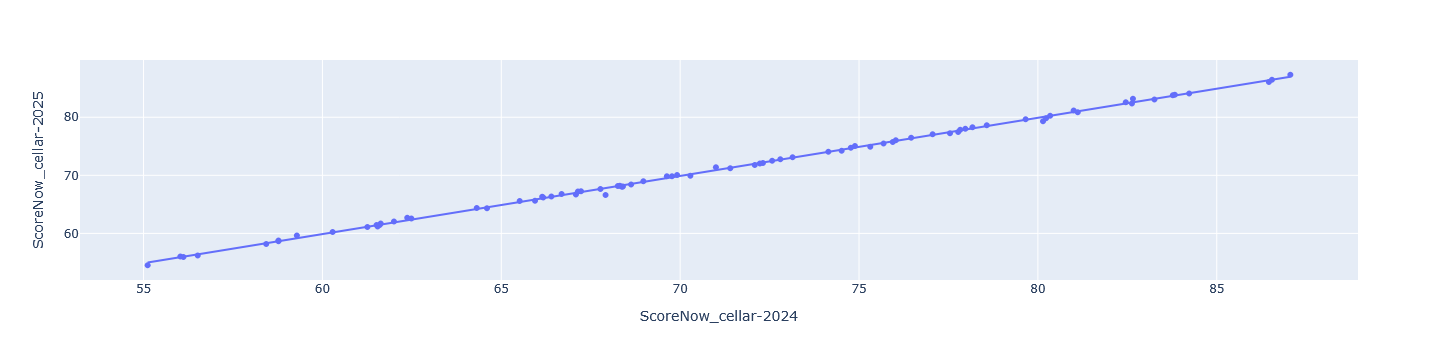

In [45]:
fig = px.scatter(full_cellar, x="ScoreNow_cellar-2024", y="ScoreNow_cellar-2025", trendline="ols")
fig.show()

In [68]:
cellar_long = pd.wide_to_long(full_cellar, ["ScoreNow_cellar","ScoreByDays_cellar","ScoreNowDifZ_cellar","ScoreNowDif_cellar","ScorediffLeft_cellar","ScorediffLeftPer_cellar"], i="Movie", j="year", sep="-")
# Resetting index? 
flat_cellar_long = cellar_long.reset_index()
flat_cellar_long

,Movie,year,Score_cellar-2024,Score_cellar-2025,Year_cellar-2024,Year_cellar-2025,ScoreNow_cellar,ScoreByDays_cellar,ScoreNowDifZ_cellar,ScoreNowDif_cellar,ScorediffLeft_cellar,ScorediffLeftPer_cellar
0,THETASTEOFTHINGS,2024,71.457143,71.457143,2023,2023,80.142857,0.026725,7.193896,8.685714,0.304304,30.430430
1,PERFECTDAYS,2024,78.771429,78.771429,2023,2023,82.657143,0.011883,3.300920,3.885714,0.183042,18.304172
2,THETEACHERSLOUNGE,2024,75.685714,75.685714,2023,2023,77.057143,0.003697,1.261742,1.371429,0.056404,5.640423
3,NYAD,2024,70.400000,70.400000,2023,2023,71.400000,0.002364,0.960499,1.000000,0.033784,3.378378
4,HOWTOHAVESEX,2024,71.571429,71.571429,2023,2023,72.314286,0.002238,0.751947,0.742857,0.026131,2.613065
...,...,...,...,...,...,...,...,...,...,...,...,...
155,THEIRONCLAW,2025,80.371429,80.371429,2023,2023,78.600000,-0.002394,-1.625263,-1.771429,-0.022041,-2.204053
156,GOLDA,2025,60.714286,60.714286,2023,2023,59.628571,-0.001264,-0.875502,-1.085714,-0.017882,-1.788235
157,POORTHINGS,2025,83.914286,83.914286,2023,2023,81.142857,-0.003676,-2.718664,-2.771429,-0.033027,-3.302690
158,THECOLORPURPLE,2025,77.257143,77.257143,2023,2023,74.057143,-0.004342,-3.187265,-3.200000,-0.041420,-4.142012


In [69]:
#Sanity check
flat_cellar_long.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 160 entries, 0 to 159
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Movie                    160 non-null    object 
 1   year                     160 non-null    int64  
 2   Score_cellar-2024        160 non-null    float64
 3   Score_cellar-2025        160 non-null    float64
 4   Year_cellar-2024         160 non-null    int64  
 5   Year_cellar-2025         160 non-null    int64  
 6   ScoreNow_cellar          160 non-null    float64
 7   ScoreByDays_cellar       160 non-null    float64
 8   ScoreNowDifZ_cellar      160 non-null    float64
 9   ScoreNowDif_cellar       160 non-null    float64
 10  ScorediffLeft_cellar     160 non-null    float64
 11  ScorediffLeftPer_cellar  160 non-null    float64
dtypes: float64(8), int64(3), object(1)
memory usage: 15.1+ KB


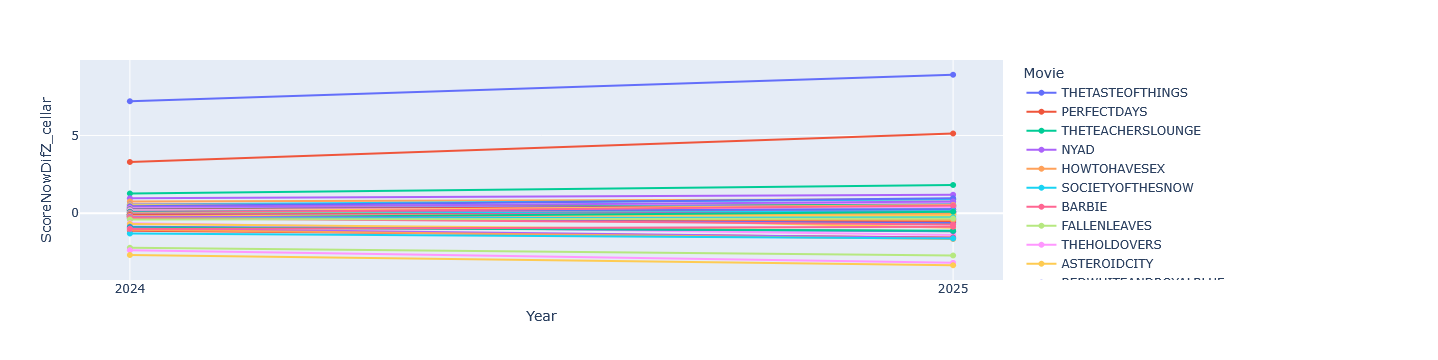

In [75]:
fig = px.line(flat_cellar_long, x="year", y="ScoreNowDifZ_cellar",color="Movie", markers=True)
fig.update_layout(
    xaxis=dict(
        title = "Year",
        tickvals=[2024, 2025]
    )
)
fig.show()